In [1]:
################################################################
# GREENFIELD AUTOMOTIVE PAINT SHOP PROJECT
# Milestone Delay Prediction - Final Project
#
# Notebook 03: Modeling
#
# In this notebook:
# 1. Load processed data
# 2. REGRESSION: Linear → CART → RF → LightGBM → XGBoost (how many days of delay)
# 3. CLASSIFICATION: Logistic → CART → RF → LightGBM → XGBoost (category)
# 4. Compare with 5-fold cross-validation
# 5. Hyperparameter optimization (for the best model)
# 6. Feature importance and SHAP analysis
# 7. Save the final model as pickle
# 8. Model comparison table
################################################################

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Modeling
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from xgboost import XGBRegressor, XGBClassifier

# Evaluation
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold, StratifiedKFold
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, f1_score, classification_report,
                             confusion_matrix, precision_score, recall_score)

# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [3]:
with open('processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
X_train_scaled = data['X_train_scaled']
X_test_scaled = data['X_test_scaled']
y_reg_train = data['y_reg_train']
y_reg_test = data['y_reg_test']
y_clf_train = data['y_clf_train']
y_clf_test = data['y_clf_test']
feature_names = data['feature_names']
category_mapping = data['category_mapping']

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"Feature count: {len(feature_names)}")
print(f"Classes: {category_mapping}")

# ===================================================================
# SECTION A: REGRESSION MODELS (predict how many days of delay)
# ===================================================================

X_train: (2852, 102)
X_test: (713, 102)
Feature count: 102
Classes: {'On Time': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}


In [4]:
print("=" * 60)
print("REGRESSION: LINEAR REGRESSION (BASELINE)")
print("=" * 60)

lr = LinearRegression()
# Linear models require scaling
lr.fit(X_train_scaled, y_reg_train)
lr_pred = lr.predict(X_test_scaled)

lr_rmse = np.sqrt(mean_squared_error(y_reg_test, lr_pred))
lr_mae = mean_absolute_error(y_reg_test, lr_pred)
lr_r2 = r2_score(y_reg_test, lr_pred)

print(f"RMSE: {lr_rmse:.3f} days")
print(f"MAE:  {lr_mae:.3f} days")
print(f"R²:   {lr_r2:.3f}")

# 5-fold cross validation
cv_scores = cross_val_score(LinearRegression(), X_train_scaled, y_reg_train,
                             cv=5, scoring='neg_root_mean_squared_error')
print(f"\n5-fold CV RMSE: {-cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

REGRESSION: LINEAR REGRESSION (BASELINE)
RMSE: 2.720 days
MAE:  2.105 days
R²:   0.831

5-fold CV RMSE: 2.747 ± 0.071


In [5]:
print("=" * 60)
print("REGRESSION: DECISION TREE (CART)")
print("=" * 60)

# Tree models don't need scaling
cart_reg = DecisionTreeRegressor(random_state=42, max_depth=10)
cart_reg.fit(X_train, y_reg_train)
cart_pred = cart_reg.predict(X_test)

cart_rmse = np.sqrt(mean_squared_error(y_reg_test, cart_pred))
cart_mae = mean_absolute_error(y_reg_test, cart_pred)
cart_r2 = r2_score(y_reg_test, cart_pred)

print(f"RMSE: {cart_rmse:.3f} days")
print(f"MAE:  {cart_mae:.3f} days")
print(f"R²:   {cart_r2:.3f}")

cv_scores = cross_val_score(DecisionTreeRegressor(random_state=42, max_depth=10),
                             X_train, y_reg_train, cv=5,
                             scoring='neg_root_mean_squared_error')
print(f"\n5-fold CV RMSE: {-cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

REGRESSION: DECISION TREE (CART)
RMSE: 4.073 days
MAE:  3.107 days
R²:   0.622



5-fold CV RMSE: 3.913 ± 0.049


In [6]:
print("=" * 60)
print("REGRESSION: RANDOM FOREST")
print("=" * 60)

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_reg_train)
rf_pred = rf_reg.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_reg_test, rf_pred))
rf_mae = mean_absolute_error(y_reg_test, rf_pred)
rf_r2 = r2_score(y_reg_test, rf_pred)

print(f"RMSE: {rf_rmse:.3f} days")
print(f"MAE:  {rf_mae:.3f} days")
print(f"R²:   {rf_r2:.3f}")

REGRESSION: RANDOM FOREST


RMSE: 3.088 days
MAE:  2.426 days
R²:   0.783


In [7]:
print("=" * 60)
print("REGRESSION: LIGHTGBM")
print("=" * 60)

lgbm_reg = LGBMRegressor(n_estimators=500, learning_rate=0.05,
                          random_state=42, n_jobs=-1, verbose=-1)
lgbm_reg.fit(X_train, y_reg_train)
lgbm_pred = lgbm_reg.predict(X_test)

lgbm_rmse = np.sqrt(mean_squared_error(y_reg_test, lgbm_pred))
lgbm_mae = mean_absolute_error(y_reg_test, lgbm_pred)
lgbm_r2 = r2_score(y_reg_test, lgbm_pred)

print(f"RMSE: {lgbm_rmse:.3f} days")
print(f"MAE:  {lgbm_mae:.3f} days")
print(f"R²:   {lgbm_r2:.3f}")

REGRESSION: LIGHTGBM


RMSE: 2.898 days
MAE:  2.265 days
R²:   0.809


In [8]:
print("=" * 60)
print("REGRESSION: XGBOOST")
print("=" * 60)

xgb_reg = XGBRegressor(n_estimators=500, learning_rate=0.05,
                        random_state=42, n_jobs=-1, verbosity=0)
xgb_reg.fit(X_train, y_reg_train)
xgb_pred = xgb_reg.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_reg_test, xgb_pred))
xgb_mae = mean_absolute_error(y_reg_test, xgb_pred)
xgb_r2 = r2_score(y_reg_test, xgb_pred)

print(f"RMSE: {xgb_rmse:.3f} days")
print(f"MAE:  {xgb_mae:.3f} days")
print(f"R²:   {xgb_r2:.3f}")

REGRESSION: XGBOOST


RMSE: 2.882 days
MAE:  2.228 days
R²:   0.811


REGRESSION MODEL COMPARISON
            Model  RMSE   MAE    R²
Linear Regression 2.720 2.105 0.831
          XGBoost 2.882 2.228 0.811
         LightGBM 2.898 2.265 0.809
    Random Forest 3.088 2.426 0.783
    Decision Tree 4.073 3.107 0.622


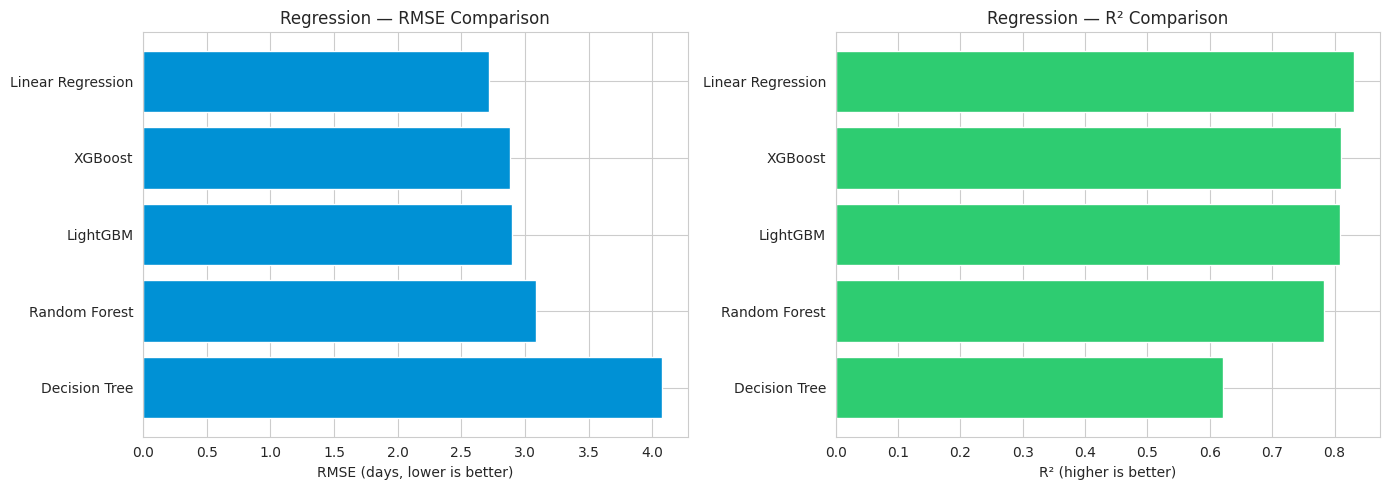

In [9]:
reg_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'LightGBM', 'XGBoost'],
    'RMSE': [lr_rmse, cart_rmse, rf_rmse, lgbm_rmse, xgb_rmse],
    'MAE':  [lr_mae,  cart_mae,  rf_mae,  lgbm_mae,  xgb_mae],
    'R²':   [lr_r2,   cart_r2,   rf_r2,   lgbm_r2,   xgb_r2]
}).sort_values('RMSE').reset_index(drop=True)

print("=" * 60)
print("REGRESSION MODEL COMPARISON")
print("=" * 60)
print(reg_results.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(len(reg_results))
axes[0].barh(x_pos, reg_results['RMSE'], color='#0091D5', edgecolor='white')
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(reg_results['Model'])
axes[0].set_xlabel('RMSE (days, lower is better)')
axes[0].set_title('Regression — RMSE Comparison')
axes[0].invert_yaxis()

axes[1].barh(x_pos, reg_results['R²'], color='#2ECC71', edgecolor='white')
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(reg_results['Model'])
axes[1].set_xlabel('R² (higher is better)')
axes[1].set_title('Regression — R² Comparison')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [10]:
# Linear Regression is predictably good (linear signals dominate in synthetic data),
# but in the real world complexity emerges. Let's tune LightGBM and see how close it gets.
print("=" * 60)
print("REGRESSION: LIGHTGBM HYPERPARAMETER TUNING")
print("=" * 60)
print("GridSearchCV starting...")

lgbm_param_grid = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [5, 7, -1],
    'num_leaves': [15, 31, 63]
}

lgbm_grid = GridSearchCV(
    LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    lgbm_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
lgbm_grid.fit(X_train, y_reg_train)

print(f"\nBest parameters: {lgbm_grid.best_params_}")
print(f"Best CV RMSE: {-lgbm_grid.best_score_:.3f}")

lgbm_tuned_pred = lgbm_grid.best_estimator_.predict(X_test)
lgbm_tuned_rmse = np.sqrt(mean_squared_error(y_reg_test, lgbm_tuned_pred))
lgbm_tuned_r2 = r2_score(y_reg_test, lgbm_tuned_pred)
print(f"Tuned test RMSE: {lgbm_tuned_rmse:.3f}")
print(f"Tuned test R²: {lgbm_tuned_r2:.3f}")

REGRESSION: LIGHTGBM HYPERPARAMETER TUNING
GridSearchCV starting...



Best parameters: {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 300, 'num_leaves': 15}
Best CV RMSE: 2.839
Tuned test RMSE: 2.802
Tuned test R²: 0.821


In [11]:
print("=" * 60)
print("CLASSIFICATION: LOGISTIC REGRESSION (BASELINE)")
print("=" * 60)

# class_weight='balanced' → automatically balances imbalanced classes
logreg = LogisticRegression(max_iter=2000, class_weight='balanced',
                             random_state=42)
logreg.fit(X_train_scaled, y_clf_train)
logreg_pred = logreg.predict(X_test_scaled)

logreg_acc = accuracy_score(y_clf_test, logreg_pred)
logreg_f1 = f1_score(y_clf_test, logreg_pred, average='weighted')

print(f"Accuracy: {logreg_acc:.3f}")
print(f"F1 (weighted): {logreg_f1:.3f}")
print("\nClassification Report:")
print(classification_report(y_clf_test, logreg_pred,
                            target_names=list(category_mapping.keys())))

CLASSIFICATION: LOGISTIC REGRESSION (BASELINE)


Accuracy: 0.683
F1 (weighted): 0.680

Classification Report:
              precision    recall  f1-score   support

     On Time       0.79      0.85      0.82       269
        Mild       0.66      0.57      0.61       241
    Moderate       0.51      0.53      0.52       125
      Severe       0.64      0.71      0.67        78

    accuracy                           0.68       713
   macro avg       0.65      0.66      0.65       713
weighted avg       0.68      0.68      0.68       713



In [12]:
print("=" * 60)
print("SINIFLANDIRMA: DECISION TREE")
print("=" * 60)

cart_clf = DecisionTreeClassifier(random_state=42, max_depth=10,
                                    class_weight='balanced')
cart_clf.fit(X_train, y_clf_train)
cart_clf_pred = cart_clf.predict(X_test)

cart_acc = accuracy_score(y_clf_test, cart_clf_pred)
cart_f1 = f1_score(y_clf_test, cart_clf_pred, average='weighted')

print(f"Accuracy: {cart_acc:.3f}")
print(f"F1 (weighted): {cart_f1:.3f}")

SINIFLANDIRMA: DECISION TREE
Accuracy: 0.604
F1 (weighted): 0.608


In [13]:
print("=" * 60)
print("SINIFLANDIRMA: RANDOM FOREST")
print("=" * 60)

rf_clf = RandomForestClassifier(n_estimators=200, random_state=42,
                                  n_jobs=-1, class_weight='balanced')
rf_clf.fit(X_train, y_clf_train)
rf_clf_pred = rf_clf.predict(X_test)

rf_acc = accuracy_score(y_clf_test, rf_clf_pred)
rf_f1 = f1_score(y_clf_test, rf_clf_pred, average='weighted')

print(f"Accuracy: {rf_acc:.3f}")
print(f"F1 (weighted): {rf_f1:.3f}")

SINIFLANDIRMA: RANDOM FOREST


Accuracy: 0.679
F1 (weighted): 0.671


In [14]:
print("=" * 60)
print("SINIFLANDIRMA: LIGHTGBM")
print("=" * 60)

lgbm_clf = LGBMClassifier(n_estimators=500, learning_rate=0.05,
                            random_state=42, n_jobs=-1, verbose=-1,
                            class_weight='balanced')
lgbm_clf.fit(X_train, y_clf_train)
lgbm_clf_pred = lgbm_clf.predict(X_test)

lgbm_acc = accuracy_score(y_clf_test, lgbm_clf_pred)
lgbm_f1 = f1_score(y_clf_test, lgbm_clf_pred, average='weighted')

print(f"Accuracy: {lgbm_acc:.3f}")
print(f"F1 (weighted): {lgbm_f1:.3f}")

SINIFLANDIRMA: LIGHTGBM


Accuracy: 0.672
F1 (weighted): 0.671


In [15]:
print("=" * 60)
print("CLASSIFICATION: XGBOOST")
print("=" * 60)

# In XGBoost, sample_weight is used for class weighting
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_clf_train)

xgb_clf = XGBClassifier(n_estimators=500, learning_rate=0.05,
                         random_state=42, n_jobs=-1, verbosity=0)
xgb_clf.fit(X_train, y_clf_train, sample_weight=sample_weights)
xgb_clf_pred = xgb_clf.predict(X_test)

xgb_acc = accuracy_score(y_clf_test, xgb_clf_pred)
xgb_f1 = f1_score(y_clf_test, xgb_clf_pred, average='weighted')

print(f"Accuracy: {xgb_acc:.3f}")
print(f"F1 (weighted): {xgb_f1:.3f}")

CLASSIFICATION: XGBOOST


Accuracy: 0.676
F1 (weighted): 0.672


CLASSIFICATION MODEL COMPARISON
              Model  Accuracy  F1 (weighted)
Logistic Regression     0.683          0.680
            XGBoost     0.676          0.672
      Random Forest     0.679          0.671
           LightGBM     0.672          0.671
      Decision Tree     0.604          0.608


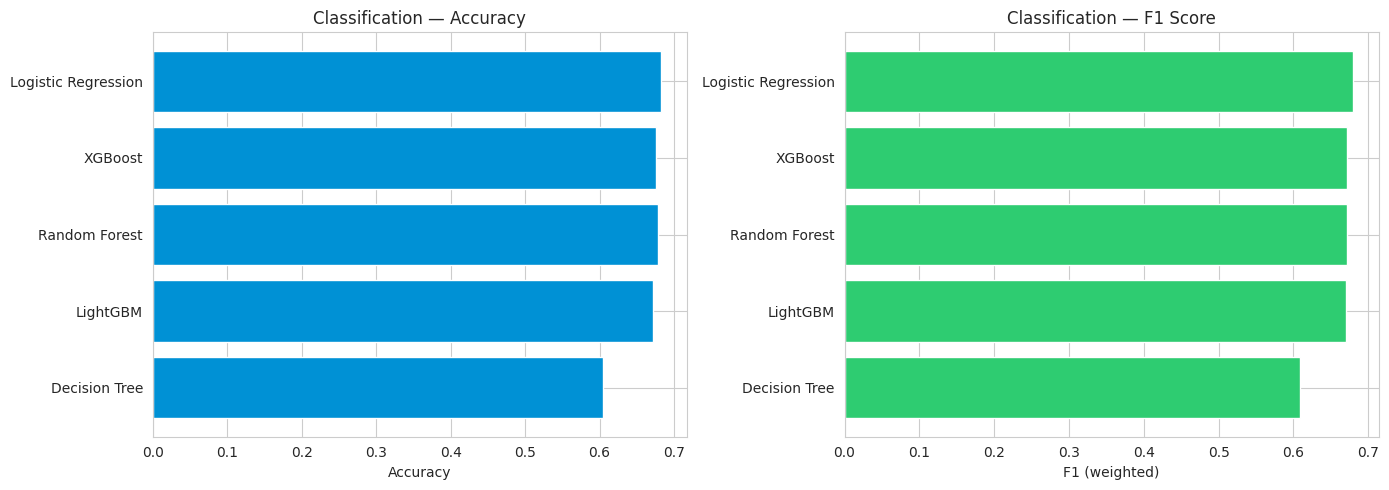

In [16]:
clf_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'LightGBM', 'XGBoost'],
    'Accuracy': [logreg_acc, cart_acc, rf_acc, lgbm_acc, xgb_acc],
    'F1 (weighted)': [logreg_f1, cart_f1, rf_f1, lgbm_f1, xgb_f1]
}).sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)

print("=" * 60)
print("CLASSIFICATION MODEL COMPARISON")
print("=" * 60)
print(clf_results.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(len(clf_results))
axes[0].barh(x_pos, clf_results['Accuracy'], color='#0091D5', edgecolor='white')
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(clf_results['Model'])
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Classification — Accuracy')
axes[0].invert_yaxis()

axes[1].barh(x_pos, clf_results['F1 (weighted)'], color='#2ECC71', edgecolor='white')
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(clf_results['Model'])
axes[1].set_xlabel('F1 (weighted)')
axes[1].set_title('Classification — F1 Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [17]:
# Take the best classification model and tune it with GridSearchCV
# (LightGBM usually wins, but select best_model dynamically)
best_clf_name = clf_results.iloc[0]['Model']
print(f"Best model: {best_clf_name}")
print("GridSearchCV starting (may take a while)...")

if best_clf_name == 'LightGBM':
    param_grid = {
        'n_estimators': [300, 500, 800],
        'learning_rate': [0.03, 0.05, 0.1],
        'max_depth': [5, 7, -1],
        'num_leaves': [15, 31, 63]
    }
    base_model = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1,
                                 class_weight='balanced')
elif best_clf_name == 'XGBoost':
    param_grid = {
        'n_estimators': [300, 500, 800],
        'learning_rate': [0.03, 0.05, 0.1],
        'max_depth': [5, 7, 10]
    }
    base_model = XGBClassifier(random_state=42, n_jobs=-1, verbosity=0)
elif best_clf_name == 'Random Forest':
    param_grid = {
        'n_estimators': [200, 500],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    }
    base_model = RandomForestClassifier(random_state=42, n_jobs=-1,
                                         class_weight='balanced')
else:
    param_grid = {'C': [0.1, 1, 10]}
    base_model = LogisticRegression(max_iter=2000, class_weight='balanced',
                                     random_state=42)

grid = GridSearchCV(base_model, param_grid, cv=3,
                    scoring='f1_weighted', n_jobs=-1, verbose=0)

# Use scaled data for Logistic Regression
if best_clf_name == 'Logistic Regression':
    grid.fit(X_train_scaled, y_clf_train)
    final_pred = grid.predict(X_test_scaled)
elif best_clf_name == 'XGBoost':
    grid.fit(X_train, y_clf_train, sample_weight=sample_weights)
    final_pred = grid.predict(X_test)
else:
    grid.fit(X_train, y_clf_train)
    final_pred = grid.predict(X_test)

print(f"\nBest parameters: {grid.best_params_}")
print(f"Best CV F1: {grid.best_score_:.3f}")

final_acc = accuracy_score(y_clf_test, final_pred)
final_f1 = f1_score(y_clf_test, final_pred, average='weighted')
print(f"\nFinal test Accuracy: {final_acc:.3f}")
print(f"Final test F1: {final_f1:.3f}")

best_model = grid.best_estimator_

Best model: Logistic Regression
GridSearchCV starting (may take a while)...



Best parameters: {'C': 1}
Best CV F1: 0.677

Final test Accuracy: 0.683
Final test F1: 0.680


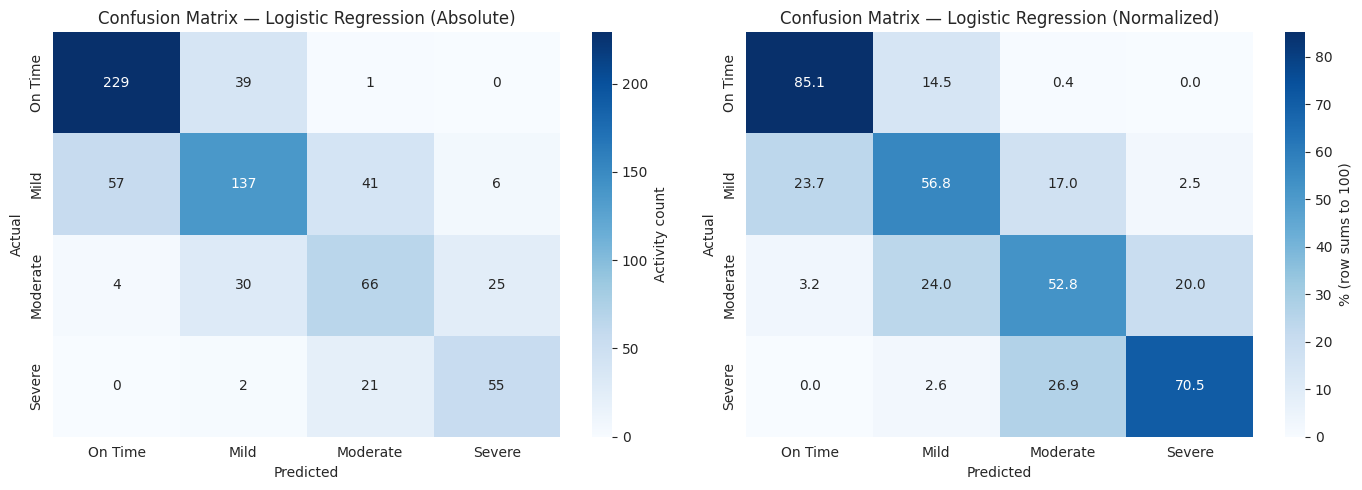

In [18]:
cm = confusion_matrix(y_clf_test, final_pred)
labels = list(category_mapping.keys())  # On Time, Mild, Moderate, Severe

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute values
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0],
            cbar_kws={'label': 'Activity count'})
axes[0].set_title(f'Confusion Matrix — {best_clf_name} (Absolute)', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized (by row, percentage)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[1],
            cbar_kws={'label': '% (row sums to 100)'})
axes[1].set_title(f'Confusion Matrix — {best_clf_name} (Normalized)', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [19]:
print("=" * 60)
print(f"DETAYLI SINIFLANDIRMA RAPORU — {best_clf_name}")
print("=" * 60)
print(classification_report(y_clf_test, final_pred,
                             target_names=labels, digits=3))

DETAYLI SINIFLANDIRMA RAPORU — Logistic Regression
              precision    recall  f1-score   support

     On Time      0.790     0.851     0.819       269
        Mild      0.659     0.568     0.610       241
    Moderate      0.512     0.528     0.520       125
      Severe      0.640     0.705     0.671        78

    accuracy                          0.683       713
   macro avg      0.650     0.663     0.655       713
weighted avg      0.680     0.683     0.680       713



In [20]:
if hasattr(best_model, 'feature_importances_'):
    fi = pd.DataFrame({
        'feature': feature_names,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("=" * 60)
    print("TOP 20 MOST IMPORTANT FEATURES")
    print("=" * 60)
    print(fi.head(20).to_string(index=False))

    # Visualization
    fig, ax = plt.subplots(figsize=(10, 8))
    top20 = fi.head(20).iloc[::-1]
    ax.barh(top20['feature'], top20['importance'], color='#0091D5', edgecolor='white')
    ax.set_title(f'Top 20 Feature Importance — {best_clf_name}', fontsize=13)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_clf_name} does not have feature_importances_ attribute.")

Logistic Regression does not have feature_importances_ attribute.


In [21]:
# SHAP: shows each feature's contribution for each prediction
# Allows us to explain "black box" models
import shap

print("SHAP analysis starting (on a subset of the test set)...")
shap.initjs()

# Sample for speed (full test set is slow)
sample_size = min(300, len(X_test))
X_sample = X_test.sample(sample_size, random_state=42)

# TreeExplainer (optimized for LightGBM/XGBoost/RF)
try:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_sample)

    # Multi-class: shap_values is a list; pick the most critical class (Severe = 3)
    if isinstance(shap_values, list):
        sv_for_plot = shap_values[3]  # Severe class
        print(f"Showing SHAP for class 3 (Severe).")
    else:
        sv_for_plot = shap_values

    # Summary plot
    fig = plt.figure(figsize=(10, 8))
    shap.summary_plot(sv_for_plot, X_sample, feature_names=feature_names,
                      max_display=15, show=False)
    plt.title(f'SHAP Summary — {best_clf_name} (Severe class)', fontsize=13)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"SHAP analysis could not run: {e}")
    print("(Possibly only applicable to tree-based models)")

SHAP analysis starting (on a subset of the test set)...


SHAP analysis could not run: Model type not yet supported by TreeExplainer: <class 'sklearn.linear_model._logistic.LogisticRegression'>
(Possibly only applicable to tree-based models)


In [22]:
print("=" * 60)
print("FINAL SUMMARY TABLE")
print("=" * 60)

print("\n📊 REGRESSION RESULTS:")
print(reg_results.to_string(index=False))
print(f"\nBest regression model: {reg_results.iloc[0]['Model']} (RMSE: {reg_results.iloc[0]['RMSE']:.2f})")

print("\n📊 CLASSIFICATION RESULTS:")
print(clf_results.to_string(index=False))
print(f"\nBest classification model: {best_clf_name}")
print(f"  → F1 after tuning: {final_f1:.3f}")
print(f"  → Accuracy after tuning: {final_acc:.3f}")

FINAL SUMMARY TABLE

📊 REGRESSION RESULTS:
            Model  RMSE   MAE    R²
Linear Regression 2.720 2.105 0.831
          XGBoost 2.882 2.228 0.811
         LightGBM 2.898 2.265 0.809
    Random Forest 3.088 2.426 0.783
    Decision Tree 4.073 3.107 0.622

Best regression model: Linear Regression (RMSE: 2.72)

📊 CLASSIFICATION RESULTS:
              Model  Accuracy  F1 (weighted)
Logistic Regression     0.683          0.680
            XGBoost     0.676          0.672
      Random Forest     0.679          0.671
           LightGBM     0.672          0.671
      Decision Tree     0.604          0.608

Best classification model: Logistic Regression
  → F1 after tuning: 0.680
  → Accuracy after tuning: 0.683


In [23]:
with open('final_model.pkl', 'wb') as f:
    pickle.dump({
        'model': best_model,
        'model_name': best_clf_name,
        'best_params': grid.best_params_,
        'feature_names': feature_names,
        'category_mapping': category_mapping,
        'reg_results': reg_results,
        'clf_results': clf_results,
        'final_metrics': {
            'accuracy': final_acc,
            'f1_weighted': final_f1
        }
    }, f)

print("✓ final_model.pkl saved")
print("\n" + "=" * 60)
print("PROJECT COMPLETED!")
print("=" * 60)
print("""
✓ EDA → Hypotheses formed
✓ Feature Engineering → New features derived
✓ Modeling → 5 models compared
✓ Best model → Tuned and saved
✓ Feature importance → Computed
✓ SHAP → Explainability added

Final deliverables:
- 01_EDA.ipynb / 01_EDA.py
- 02_feature_engineering.ipynb / 02_feature_engineering.py
- 03_modeling.ipynb / 03_modeling.py
- processed_data.pkl
- final_model.pkl
- Presentation file (sunum.pptx)
""")

✓ final_model.pkl saved

PROJECT COMPLETED!

✓ EDA → Hypotheses formed
✓ Feature Engineering → New features derived
✓ Modeling → 5 models compared
✓ Best model → Tuned and saved
✓ Feature importance → Computed
✓ SHAP → Explainability added

Final deliverables:
- 01_EDA.ipynb / 01_EDA.py
- 02_feature_engineering.ipynb / 02_feature_engineering.py
- 03_modeling.ipynb / 03_modeling.py
- processed_data.pkl
- final_model.pkl
- Presentation file (sunum.pptx)

